In [4]:
import cdsapi
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("All packages imported successfully")

All packages imported successfully


In [5]:
# Site: Sydney Basin / NSW South Coast
LAT = -34.0
LON = 151.0

REQUEST = {
    "product_type": "reanalysis",
    "variable": [
        "100m_u_component_of_wind",
        "100m_v_component_of_wind"
    ],
    "year": [str(y) for y in range(2019, 2024)],
    "month": [f"{m:02d}" for m in range(1, 13)],
    "day": [f"{d:02d}" for d in range(1, 32)],
    "time": [f"{h:02d}:00" for h in range(24)],
    "area": [LAT + 1, LON - 1, LAT - 1, LON + 1],
    "data_format": "netcdf",
    "download_format": "unarchived"
}

print("Request defined successfully")

Request defined successfully


In [6]:
import os

client = cdsapi.Client()

years = [2019, 2020, 2021, 2022, 2023]

for year in years:
    output_path = f"../data/raw/era5_sydney_{year}.nc"
    
    # Skip if already downloaded
    if os.path.exists(output_path):
        print(f"{year} already downloaded, skipping")
        continue
    
    request = {
        "product_type": "reanalysis",
        "variable": [
            "100m_u_component_of_wind",
            "100m_v_component_of_wind"
        ],
        "year": str(year),
        "month": [f"{m:02d}" for m in range(1, 13)],
        "day": [f"{d:02d}" for d in range(1, 32)],
        "time": [f"{h:02d}:00" for h in range(24)],
        "area": [LAT + 1, LON - 1, LAT - 1, LON + 1],
        "data_format": "netcdf",
        "download_format": "unarchived"
    }
    
    print(f"Requesting {year}...")
    client.retrieve("reanalysis-era5-single-levels", request, output_path)
    print(f"{year} downloaded successfully")

print("All years complete")

Requesting 2019...


2026-05-24 13:04:04,660 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-05-24 13:04:04,662 INFO Request ID is b6e86132-3ad6-4659-9371-0ebd79a0dd91
2026-05-24 13:04:05,047 INFO status has been updated to accepted
2026-05-24 13:04:30,264 INFO status has been updated to running
2026-05-24 13:18:42,603 INFO status has been updated to successful


2019 downloaded successfully
Requesting 2020...


2026-05-24 13:18:56,851 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-05-24 13:18:56,854 INFO Request ID is 24a71592-ddb8-4784-a715-39723301dd68
2026-05-24 13:18:57,228 INFO status has been updated to accepted
2026-05-24 13:19:12,868 INFO status has been updated to running
2026-05-24 13:33:31,642 INFO status has been updated to successful


2020 downloaded successfully
Requesting 2021...


...

2021 downloaded successfully
Requesting 2022...


2026-05-24 13:50:32,650 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-05-24 13:50:32,655 INFO Request ID is 7db397ca-0ecc-4fe5-8caf-845b0e10a655
2026-05-24 13:50:35,396 INFO status has been updated to accepted
2026-05-24 13:50:50,441 INFO status has been updated to running
2026-05-24 14:05:12,859 INFO status has been updated to successful


2022 downloaded successfully
Requesting 2023...


2026-05-24 14:05:23,616 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-05-24 14:05:23,618 INFO Request ID is cd4470b2-1f26-4ac9-9d32-3f3f73695bd1
2026-05-24 14:05:24,010 INFO status has been updated to accepted
2026-05-24 14:05:41,407 INFO status has been updated to running
2026-05-24 14:20:02,028 INFO status has been updated to successful
                                                                                        

2023 downloaded successfully
All years complete


In [6]:
ds_2019 = xr.open_dataset("../data/raw/era5_sydney_2019.nc")

# Print the full dataset structure
print(ds_2019)

<xarray.Dataset> Size: 6MB
Dimensions:     (valid_time: 8760, latitude: 9, longitude: 9)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 70kB 2019-01-01 ... 2019-12-31T23...
    expver      (valid_time) <U4 140kB ...
  * latitude    (latitude) float64 72B -33.0 -33.25 -33.5 ... -34.5 -34.75 -35.0
  * longitude   (longitude) float64 72B 150.0 150.2 150.5 ... 151.5 151.8 152.0
    number      int64 8B ...
Data variables:
    u100        (valid_time, latitude, longitude) float32 3MB ...
    v100        (valid_time, latitude, longitude) float32 3MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-24T03:18 GRIB to CDM+CF via cfgrib-0.9.1...


In [7]:
print("=== TIME ===")
print(f"First timestamp: {ds_2019.valid_time.values[0]}")
print(f"Last timestamp: {ds_2019.valid_time.values[-1]}")
print(f"Total timesteps: {len(ds_2019.valid_time)}")
print(f"Expected timesteps: {365 * 24} (non-leap) or {366 * 24} (leap)")

print("\n=== LATITUDE ===")
print(ds_2019.latitude.values)

print("\n=== LONGITUDE ===")
print(ds_2019.longitude.values)

print("\n=== VARIABLES ===")
print(f"u100 units: {ds_2019.u100.attrs.get('units', 'not specified')}")
print(f"v100 units: {ds_2019.v100.attrs.get('units', 'not specified')}")

=== TIME ===
First timestamp: 2019-01-01T00:00:00.000000000
Last timestamp: 2019-12-31T23:00:00.000000000
Total timesteps: 8760
Expected timesteps: 8760 (non-leap) or 8784 (leap)

=== LATITUDE ===
[-33.   -33.25 -33.5  -33.75 -34.   -34.25 -34.5  -34.75 -35.  ]

=== LONGITUDE ===
[150.   150.25 150.5  150.75 151.   151.25 151.5  151.75 152.  ]

=== VARIABLES ===
u100 units: m s**-1
v100 units: m s**-1


In [8]:
# Target coordinates — Sydney Basin
TARGET_LAT = -34.0
TARGET_LON = 151.75

# Select nearest grid point to target coordinates
# method="nearest" finds the closest coordinate value in the grid
ds_point = ds_2019.sel(
    latitude=TARGET_LAT,
    longitude=TARGET_LON,
    method="nearest"
)

# Confirm which grid point was selected
print(f"Target coordinates:   {TARGET_LAT}°N, {TARGET_LON}°E")
print(f"Selected grid point:  {float(ds_point.latitude):.4f}°N, {float(ds_point.longitude):.4f}°E")
print(f"\nData shape after selection:")
print(f"  u100: {ds_point.u100.values.shape}")
print(f"  v100: {ds_point.v100.values.shape}")
print(f"\nDataset now has dimensions: {dict(ds_point.dims)}")

Target coordinates:   -34.0°N, 151.75°E
Selected grid point:  -34.0000°N, 151.7500°E

Data shape after selection:
  u100: (8760,)
  v100: (8760,)

Dataset now has dimensions: {'valid_time': 8760}


C:\Users\Aidan\AppData\Local\Temp\ipykernel_2928\513649684.py:19: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"\nDataset now has dimensions: {dict(ds_point.dims)}")


In [9]:
# Extract raw component arrays from the xarray dataset into numpy arrays
u = ds_point.u100.values  # eastward wind component, m/s
v = ds_point.v100.values  # northward wind component, m/s
time = ds_point.valid_time.values

print(f"Array type: {type(u)}")
print(f"Array shape: {u.shape}")
print(f"Sample u values (first 5): {u[:5].round(3)} m/s")
print(f"Sample v values (first 5): {v[:5].round(3)} m/s")

wind_speed = np.sqrt(u**2 + v**2)

print(f"\n=== WIND SPEED DIAGNOSTICS ===")
print(f"  Mean:              {wind_speed.mean():.2f} m/s")
print(f"  Median:            {np.median(wind_speed):.2f} m/s")
print(f"  Std deviation:     {wind_speed.std():.2f} m/s")
print(f"  Max:               {wind_speed.max():.2f} m/s")
print(f"  Min:               {wind_speed.min():.2f} m/s")
print(f"  % below cut-in (3 m/s): {(wind_speed < 3.0).mean() * 100:.1f}%")
print(f"  % above rated (~12 m/s): {(wind_speed > 12.0).mean() * 100:.1f}%")
print(f"  % above cut-out (25 m/s): {(wind_speed > 25.0).mean() * 100:.1f}%")

Array type: <class 'numpy.ndarray'>
Array shape: (8760,)
Sample u values (first 5): [-1.204 -0.873 -0.607 -0.938 -1.786] m/s
Sample v values (first 5): [-6.39  -6.765 -5.956 -4.602 -4.012] m/s

=== WIND SPEED DIAGNOSTICS ===
  Mean:              7.73 m/s
  Median:            7.23 m/s
  Std deviation:     3.90 m/s
  Max:               23.21 m/s
  Min:               0.06 m/s
  % below cut-in (3 m/s): 10.0%
  % above rated (~12 m/s): 15.9%
  % above cut-out (25 m/s): 0.0%


In [10]:
# correcting wind direction for meteorological standards
wind_direction = (270 - np.degrees(np.arctan2(v, u))) % 360

print(f"=== WIND DIRECTION DIAGNOSTICS ===")
print(f"  Range: {wind_direction.min():.1f}° to {wind_direction.max():.1f}°")
print(f"  Mean:  {wind_direction.mean():.1f}°")

# Break down by compass sector
sectors = {
    "North (315–45°)":    ((wind_direction >= 315) | (wind_direction < 45)).mean() * 100,
    "East (45–135°)":     ((wind_direction >= 45)  & (wind_direction < 135)).mean() * 100,
    "South (135–225°)":   ((wind_direction >= 135) & (wind_direction < 225)).mean() * 100,
    "West (225–315°)":    ((wind_direction >= 225) & (wind_direction < 315)).mean() * 100,
}

print(f"\n  Directional frequency breakdown:")
for sector, freq in sectors.items():
    bar = "█" * int(freq / 2)
    print(f"  {sector:<25} {freq:5.1f}%  {bar}")

=== WIND DIRECTION DIAGNOSTICS ===
  Range: 0.1° to 360.0°
  Mean:  159.5°

  Directional frequency breakdown:
  North (315–45°)            35.3%  █████████████████
  East (45–135°)             16.3%  ████████
  South (135–225°)           28.7%  ██████████████
  West (225–315°)            19.7%  █████████


In [11]:
# convert to pandas dataframe for time indexing
df_2019 = pd.DataFrame({
    "u100":           u,
    "v100":           v,
    "wind_speed":     wind_speed,
    "wind_direction": wind_direction
}, index=pd.to_datetime(time))

df_2019.index.name = "time"

print("DataFrame structure:")
print(df_2019.head(10))
print(f"\nShape: {df_2019.shape}  ({df_2019.shape[0]} rows × {df_2019.shape[1]} columns)")
print(f"\nData types:\n{df_2019.dtypes}")
print(f"\nMissing values:\n{df_2019.isnull().sum()}")

DataFrame structure:
                         u100      v100  wind_speed  wind_direction
time                                                               
2019-01-01 00:00:00 -1.203949 -6.389709    6.502144       10.670563
2019-01-01 01:00:00 -0.872925 -6.765488    6.821570        7.352020
2019-01-01 02:00:00 -0.607254 -5.956268    5.987144        5.821289
2019-01-01 03:00:00 -0.938156 -4.601562    4.696223       11.523407
2019-01-01 04:00:00 -1.786484 -4.011780    4.391572       24.003845
2019-01-01 05:00:00 -3.923264 -5.752090    6.962653       34.296265
2019-01-01 06:00:00 -5.684448 -8.244461   10.014194       34.585754
2019-01-01 07:00:00 -5.264526 -8.692871   10.162738       31.199707
2019-01-01 08:00:00 -4.993729 -8.617706    9.960030       30.091125
2019-01-01 09:00:00 -5.230682 -8.050903    9.600890       33.011841

Shape: (8760, 4)  (8760 rows × 4 columns)

Data types:
u100              float32
v100              float32
wind_speed        float32
wind_direction    float32
dty

In [12]:
df_2019['month'] = df_2019.index.month
df_2019['season'] = df_2019.index.month.map({
    12: "Summer", 1: "Summer", 2: "Summer",   # Southern Hemisphere
    3: "Autumn", 4: "Autumn", 5: "Autumn",
    6: "Winter", 7: "Winter", 8: "Winter",
    9: "Spring", 10: "Spring", 11: "Spring"
})

monthly = df_2019.groupby('month')['wind_speed'].agg(['mean','std', 'max'])
monthly.index = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"]

print("Monthly wind speed statistics (m/s):")
print(f"{'Month':<6} {'Mean':>6} {'Std':>6} {'Max':>7}")
print("-" * 28)
for month, row in monthly.iterrows():
    print(f"{month:<6} {row['mean']:>6.2f} {row['std']:>6.2f} {row['max']:>7.2f} ")

# Seasonal means
print(f"\nSeasonal mean wind speeds:")
print(df_2019.groupby("season")["wind_speed"].mean().round(2))

Monthly wind speed statistics (m/s):
Month    Mean    Std     Max
----------------------------
Jan      8.28   3.83   17.27 
Feb      7.72   3.04   17.29 
Mar      7.48   3.53   18.45 
Apr      5.61   2.98   18.03 
May      7.93   4.37   19.90 
Jun      7.39   3.64   23.21 
Jul      7.60   3.40   17.34 
Aug      8.19   4.92   21.95 
Sep      8.25   4.52   22.25 
Oct      7.41   3.70   17.45 
Nov      8.50   3.97   19.59 
Dec      8.37   3.51   19.23 

Seasonal mean wind speeds:
season
Autumn    7.02
Spring    8.04
Summer    8.14
Winter    7.73
Name: wind_speed, dtype: float32


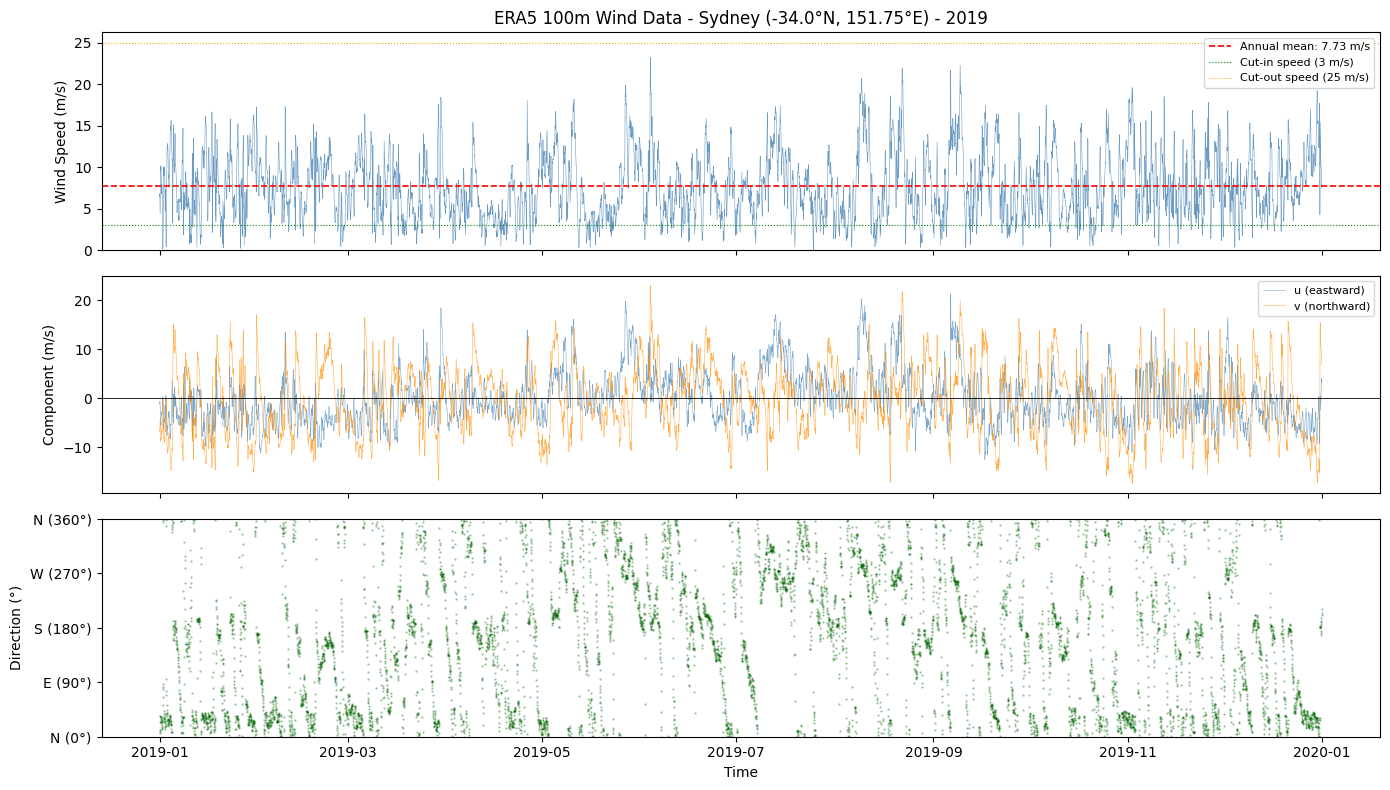

Figure saved


In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# --- Panel 1: Wind Speed ---
axes[0].plot(df_2019.index, df_2019["wind_speed"], 
             linewidth=0.4, color="steelblue", alpha=0.8)
axes[0].axhline(df_2019["wind_speed"].mean(), 
                color="red", linewidth=1.2, linestyle="--",
                label=f"Annual mean: {df_2019['wind_speed'].mean():.2f} m/s")
axes[0].axhline(3.0, color="green", linewidth=0.8, linestyle=":", 
                label="Cut-in speed (3 m/s)")
axes[0].axhline(25.0, color="orange", linewidth=0.8, linestyle=":", 
                label="Cut-out speed (25 m/s)")
axes[0].set_ylabel("Wind Speed (m/s)")
axes[0].set_title("ERA5 100m Wind Data - Sydney (-34.0°N, 151.75°E) - 2019")
axes[0].legend(fontsize=8, loc="upper right")
axes[0].set_ylim(0, None)

# --- Panel 2: U and V Components ---
# Plotting raw components shows the vector nature of wind
# When u is strongly positive, wind is blowing eastward (westerly wind)
# When v is strongly positive, wind is blowing northward (southerly wind)
axes[1].plot(df_2019.index, df_2019["u100"], 
             linewidth=0.4, color="steelblue", alpha=0.7, label="u (eastward)")
axes[1].plot(df_2019.index, df_2019["v100"], 
             linewidth=0.4, color="darkorange", alpha=0.7, label="v (northward)")
axes[1].axhline(0, color="black", linewidth=0.6, linestyle="-")
axes[1].set_ylabel("Component (m/s)")
axes[1].legend(fontsize=8, loc="upper right")

# --- Panel 3: Wind Direction ---
# Plotted as scatter rather than line because direction is circular
# A line plot connects 359° to 1° through 180° which is misleading
axes[2].scatter(df_2019.index, df_2019["wind_direction"], 
                s=0.3, color="darkgreen", alpha=0.4)
axes[2].set_ylabel("Direction (°)")
axes[2].set_xlabel("Time")
axes[2].set_ylim(0, 360)
axes[2].set_yticks([0, 90, 180, 270, 360])
axes[2].set_yticklabels(["N (0°)", "E (90°)", "S (180°)", "W (270°)", "N (360°)"])

plt.tight_layout()
plt.savefig("../outputs/figures/01_raw_timeseries_2019.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved")

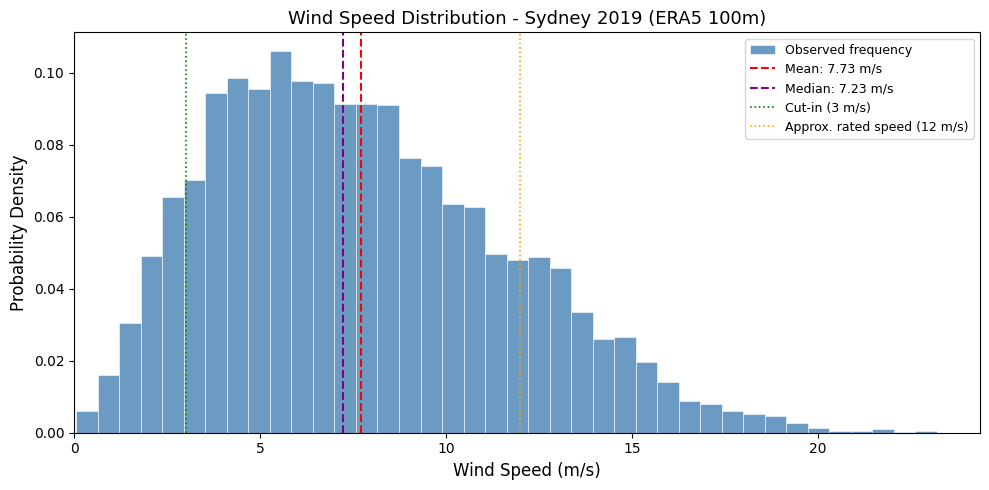

Most frequent wind speed bin: 5.3–5.8 m/s
Mean > Median: 7.73 > 7.23
This confirms right-skew - more high-speed events pulling the mean above the median
This right-skew is exactly what Weibull is designed to capture


In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

# Plot histogram of wind speeds
# density=True normalises so the y-axis is probability density
# This allows direct visual comparison with the Weibull PDF later
n, bins, patches = ax.hist(df_2019["wind_speed"], 
                            bins=40, 
                            density=True,
                            color="steelblue", 
                            edgecolor="white", 
                            linewidth=0.5,
                            alpha=0.8,
                            label="Observed frequency")

# Add vertical lines for key reference speeds
ax.axvline(df_2019["wind_speed"].mean(), 
           color="red", linewidth=1.5, linestyle="--",
           label=f"Mean: {df_2019['wind_speed'].mean():.2f} m/s")
ax.axvline(df_2019["wind_speed"].median(), 
           color="purple", linewidth=1.5, linestyle="--",
           label=f"Median: {df_2019['wind_speed'].median():.2f} m/s")
ax.axvline(3.0, color="green", linewidth=1.2, linestyle=":",
           label="Cut-in (3 m/s)")
ax.axvline(12.0, color="orange", linewidth=1.2, linestyle=":",
           label="Approx. rated speed (12 m/s)")

ax.set_xlabel("Wind Speed (m/s)", fontsize=12)
ax.set_ylabel("Probability Density", fontsize=12)
ax.set_title("Wind Speed Distribution - Sydney 2019 (ERA5 100m)", fontsize=13)
ax.legend(fontsize=9)
ax.set_xlim(0, None)

plt.tight_layout()
plt.savefig("../outputs/figures/02_wind_speed_histogram_2019.png", dpi=150, bbox_inches="tight")
plt.show()

# Print bin statistics for reference
print(f"Most frequent wind speed bin: {bins[n.argmax()]:.1f}–{bins[n.argmax()+1]:.1f} m/s")
print(f"Mean > Median: {df_2019['wind_speed'].mean():.2f} > {df_2019['wind_speed'].median():.2f}")
print("This confirms right-skew - more high-speed events pulling the mean above the median")
print("This right-skew is exactly what Weibull is designed to capture")

C:\Users\Aidan\AppData\Local\Temp\ipykernel_2928\195540084.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(monthly_data,


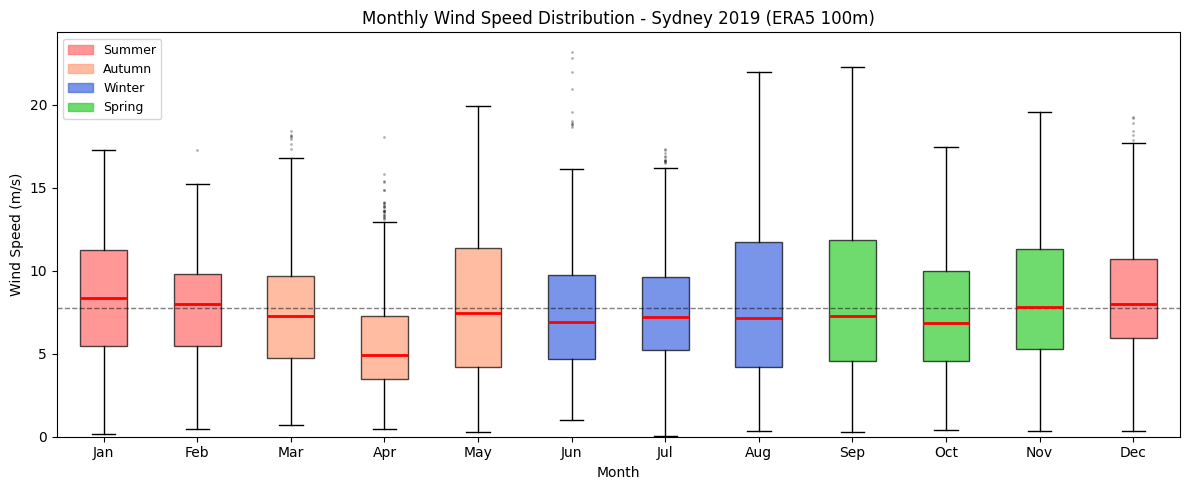

In [18]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 5))

# Group data by month for box plotting
monthly_data = [df_2019[df_2019["month"] == m]["wind_speed"].values 
                for m in range(1, 13)]

month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

# Create box plot
bp = ax.boxplot(monthly_data, 
                labels=month_labels,
                patch_artist=True,
                medianprops=dict(color="red", linewidth=2),
                flierprops=dict(marker=".", markersize=2, alpha=0.3))

# Colour boxes by season — Southern Hemisphere convention
season_colours = {
    "Summer": "#FF6B6B",   # Dec, Jan, Feb
    "Autumn": "#FFA07A",   # Mar, Apr, May  
    "Winter": "#4169E1",   # Jun, Jul, Aug
    "Spring": "#32CD32"    # Sep, Oct, Nov
}

month_seasons = ["Summer","Summer","Autumn","Autumn","Autumn",
                 "Winter","Winter","Winter","Spring","Spring","Spring","Summer"]

for patch, season in zip(bp["boxes"], month_seasons):
    patch.set_facecolor(season_colours[season])
    patch.set_alpha(0.7)

# Add legend for seasons
legend_patches = [mpatches.Patch(color=v, alpha=0.7, label=k) 
                  for k, v in season_colours.items()]
ax.legend(handles=legend_patches, fontsize=9, loc="upper left")

ax.axhline(df_2019["wind_speed"].mean(), color="black", 
           linewidth=1, linestyle="--", alpha=0.5,
           label="Annual mean")
ax.set_xlabel("Month")
ax.set_ylabel("Wind Speed (m/s)")
ax.set_title("Monthly Wind Speed Distribution - Sydney 2019 (ERA5 100m)")
ax.set_ylim(0, None)

plt.tight_layout()
plt.savefig("../outputs/figures/03_monthly_boxplot_2019.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# Check proportion of near-zero wind speeds
calm_threshold = 0.5  # m/s - below this considered effectively calm
n_calm = (df_2019["wind_speed"] < calm_threshold).sum()
pct_calm = (df_2019["wind_speed"] < calm_threshold).mean() * 100

print(f"Hours below {calm_threshold} m/s: {n_calm} ({pct_calm:.1f}%)")
print(f"Hours used for Weibull fit: {len(df_2019) - n_calm} ({100 - pct_calm:.1f}%)")

Hours below 0.5 m/s: 22 (0.3%)
Hours used for Weibull fit: 8738 (99.7%)


In [20]:
from scipy import stats

# Filter out near-calm hours for fitting
# Weibull is defined for U > 0; near-zero values can distort MLE
fit_speeds = df_2019["wind_speed"][df_2019["wind_speed"] >= 0.5].values

# Fit Weibull distribution using Maximum Likelihood Estimation
# CRITICAL: fix loc=0 to enforce two-parameter Weibull
# Without this, scipy fits a three-parameter shifted distribution
# which has no physical meaning for wind speeds (can't have negative wind speed)
# floc=0 tells scipy to fix the location parameter at zero
shape, loc, scale = stats.weibull_min.fit(fit_speeds, floc=0)

# Map scipy parameter names to wind energy convention
k = shape      # shape parameter — controls distribution width
lam = scale    # scale parameter (λ) in m/s — controls characteristic speed

print("=== WEIBULL FIT RESULTS ===")
print(f"  Shape parameter  k:  {k:.4f}  (dimensionless)")
print(f"  Scale parameter  λ:  {lam:.4f}  m/s")
print(f"  Location parameter:  {loc:.4f}  (fixed at zero by definition)")

# Derive mean wind speed from Weibull parameters analytically
# The Weibull mean is: λ × Γ(1 + 1/k)
# where Γ is the gamma function
# This should be close to your observed mean — a sanity check on the fit
import math
weibull_mean = lam * math.gamma(1 + 1/k)
print(f"\n=== SANITY CHECK ===")
print(f"  Observed mean wind speed:  {df_2019['wind_speed'].mean():.4f} m/s")
print(f"  Weibull theoretical mean:  {weibull_mean:.4f} m/s")
print(f"  Difference:                {abs(df_2019['wind_speed'].mean() - weibull_mean):.4f} m/s")

# Physical interpretation of k value
print(f"\n=== PHYSICAL INTERPRETATION ===")
if k < 1.5:
    print(f"  k = {k:.2f} — Highly variable winds, frequent calms and storm events")
elif k < 2.0:
    print(f"  k = {k:.2f} — Variable winds, typical of mid-latitude synoptic regime")
elif k < 2.5:
    print(f"  k = {k:.2f} — Moderately consistent winds")
elif k < 3.0:
    print(f"  k = {k:.2f} — Consistent winds, approaching trade wind character")
else:
    print(f"  k = {k:.2f} — Highly consistent winds, characteristic of trade wind regime")

=== WEIBULL FIT RESULTS ===
  Shape parameter  k:  2.1109  (dimensionless)
  Scale parameter  λ:  8.7630  m/s
  Location parameter:  0.0000  (fixed at zero by definition)

=== SANITY CHECK ===
  Observed mean wind speed:  7.7301 m/s
  Weibull theoretical mean:  7.7611 m/s
  Difference:                0.0310 m/s

=== PHYSICAL INTERPRETATION ===
  k = 2.11 — Moderately consistent winds


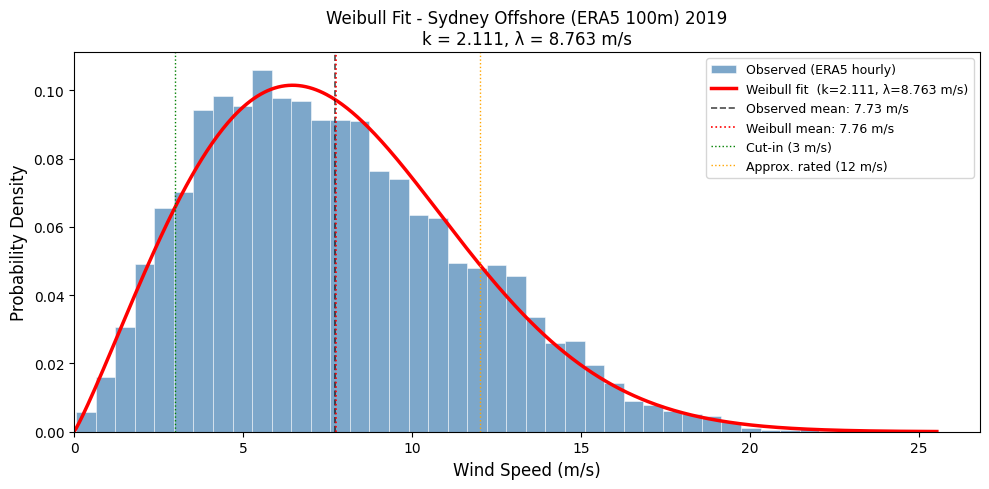

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

# Plot empirical histogram — density=True for direct PDF comparison
ax.hist(df_2019["wind_speed"],
        bins=40,
        density=True,
        color="steelblue",
        edgecolor="white",
        linewidth=0.5,
        alpha=0.7,
        label="Observed (ERA5 hourly)")

# Generate smooth Weibull PDF curve over the speed range
u_range = np.linspace(0, df_2019["wind_speed"].max() * 1.1, 500)
pdf_values = stats.weibull_min.pdf(u_range, c=k, loc=0, scale=lam)

ax.plot(u_range, pdf_values,
        color="red",
        linewidth=2.5,
        label=f"Weibull fit  (k={k:.3f}, λ={lam:.3f} m/s)")

# Reference lines
ax.axvline(df_2019["wind_speed"].mean(),
           color="black", linewidth=1.2, linestyle="--", alpha=0.7,
           label=f"Observed mean: {df_2019['wind_speed'].mean():.2f} m/s")
ax.axvline(weibull_mean,
           color="red", linewidth=1.2, linestyle=":",
           label=f"Weibull mean: {weibull_mean:.2f} m/s")
ax.axvline(3.0, color="green", linewidth=1.0, linestyle=":",
           label="Cut-in (3 m/s)")
ax.axvline(12.0, color="orange", linewidth=1.0, linestyle=":",
           label="Approx. rated (12 m/s)")

ax.set_xlabel("Wind Speed (m/s)", fontsize=12)
ax.set_ylabel("Probability Density", fontsize=12)
ax.set_title(f"Weibull Fit - Sydney Offshore (ERA5 100m) 2019\n"
             f"k = {k:.3f}, λ = {lam:.3f} m/s", fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(0, None)

plt.tight_layout()
plt.savefig("../outputs/figures/04_weibull_fit_2019.png", dpi=150, bbox_inches="tight")
plt.show()

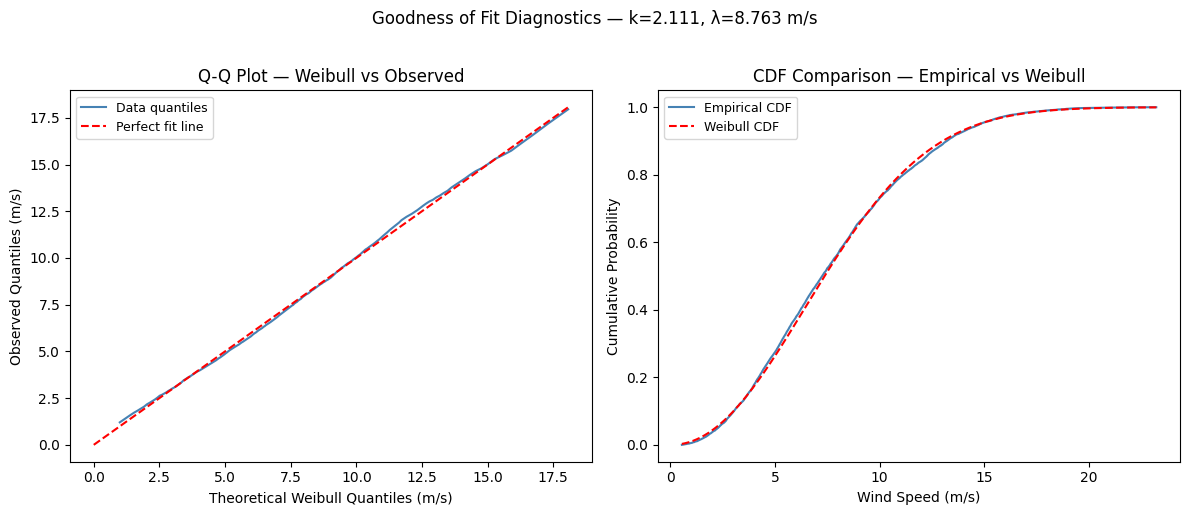

=== KOLMOGOROV-SMIRNOV TEST ===
  KS statistic D:  0.0186  (max CDF deviation)
  p-value:         0.0048

  Result: Weibull hypothesis rejected (p < 0.05)
  Interpretation: Significant deviation from Weibull — note as limitation
  Note: With 8000+ samples the KS test is very sensitive —
  small deviations that are practically insignificant will be flagged


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Q-Q Plot ---
# Quantile-Quantile plot: theoretical Weibull quantiles vs observed quantiles
# A perfect fit produces a straight diagonal line
# Deviations at the tails indicate where Weibull misrepresents the data

# Generate theoretical quantiles from fitted Weibull
quantiles = np.linspace(0.01, 0.99, 200)
theoretical_q = stats.weibull_min.ppf(quantiles, c=k, loc=0, scale=lam)
observed_q = np.quantile(fit_speeds, quantiles)

axes[0].plot(theoretical_q, observed_q,
             color="steelblue", linewidth=1.5, label="Data quantiles")
axes[0].plot([0, theoretical_q.max()], [0, theoretical_q.max()],
             color="red", linewidth=1.5, linestyle="--", label="Perfect fit line")
axes[0].set_xlabel("Theoretical Weibull Quantiles (m/s)")
axes[0].set_ylabel("Observed Quantiles (m/s)")
axes[0].set_title("Q-Q Plot — Weibull vs Observed")
axes[0].legend(fontsize=9)

# --- CDF Comparison ---
# Empirical CDF vs theoretical Weibull CDF
# Shows cumulative probability — what fraction of hours are below each speed
sorted_speeds = np.sort(fit_speeds)
empirical_cdf = np.arange(1, len(sorted_speeds) + 1) / len(sorted_speeds)
theoretical_cdf = stats.weibull_min.cdf(sorted_speeds, c=k, loc=0, scale=lam)

axes[1].plot(sorted_speeds, empirical_cdf,
             color="steelblue", linewidth=1.5, label="Empirical CDF")
axes[1].plot(sorted_speeds, theoretical_cdf,
             color="red", linewidth=1.5, linestyle="--", label="Weibull CDF")
axes[1].set_xlabel("Wind Speed (m/s)")
axes[1].set_ylabel("Cumulative Probability")
axes[1].set_title("CDF Comparison — Empirical vs Weibull")
axes[1].legend(fontsize=9)

plt.suptitle(f"Goodness of Fit Diagnostics — k={k:.3f}, λ={lam:.3f} m/s", 
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/05_weibull_diagnostics_2019.png", 
            dpi=150, bbox_inches="tight")
plt.show()

# --- Kolmogorov-Smirnov Test ---
# KS test measures the maximum distance between empirical and theoretical CDF
# D statistic: smaller = better fit
# p-value: above 0.05 means we cannot reject the Weibull hypothesis
ks_stat, ks_p = stats.kstest(fit_speeds, 
                              lambda x: stats.weibull_min.cdf(x, c=k, loc=0, scale=lam))

print("=== KOLMOGOROV-SMIRNOV TEST ===")
print(f"  KS statistic D:  {ks_stat:.4f}  (max CDF deviation)")
print(f"  p-value:         {ks_p:.4f}")
print()
if ks_p > 0.05:
    print("  Result: Cannot reject Weibull hypothesis (p > 0.05)")
    print("  Interpretation: Weibull is a statistically acceptable fit")
else:
    print("  Result: Weibull hypothesis rejected (p < 0.05)")
    print("  Interpretation: Significant deviation from Weibull — note as limitation")
    print("  Note: With 8000+ samples the KS test is very sensitive —")
    print("  small deviations that are practically insignificant will be flagged")

C:\Users\Aidan\AppData\Local\Temp\ipykernel_10176\1301185248.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


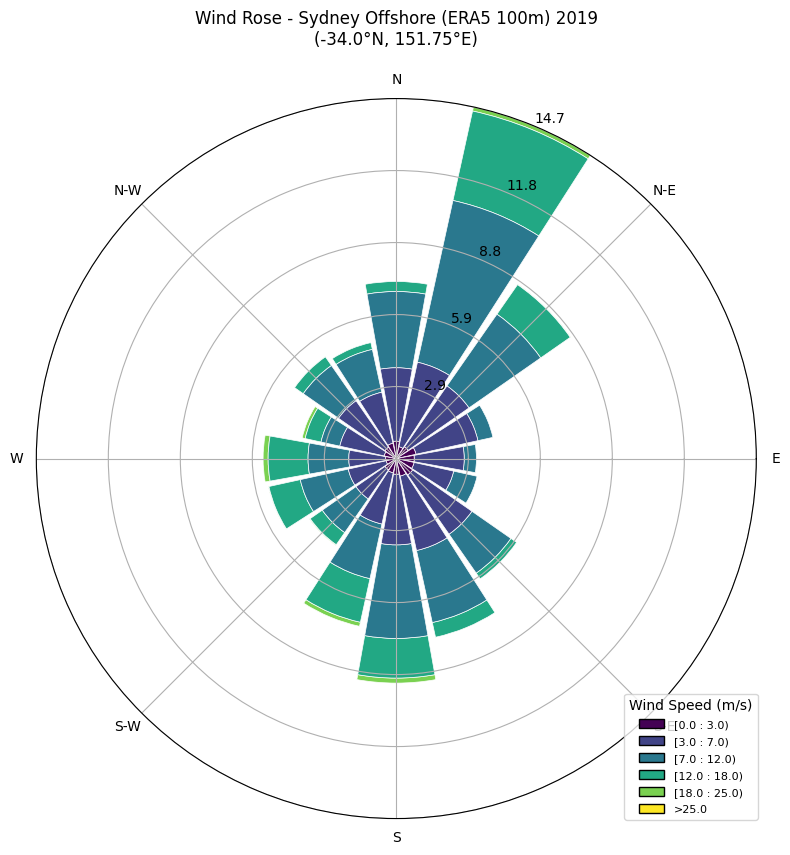

In [17]:
from windrose import WindroseAxes

fig = plt.figure(figsize=(9, 9))
ax = WindroseAxes.from_ax(fig=fig)

# Plot wind rose with speed bins matching turbine operational regions
# Bin boundaries chosen deliberately:
# 0-3 m/s   = below cut-in, zero generation
# 3-7 m/s   = lower power zone, cubic region of power curve
# 7-12 m/s  = upper power zone, approaching rated
# 12-18 m/s = at or near rated power output
# 18+ m/s   = high wind, rated output until cut-out
ax.bar(df_2019["wind_direction"],
       df_2019["wind_speed"],
       normed=True,           # normalise to percentage frequency
       opening=0.9,           # slight gap between petals for readability
       edgecolor="white",
       linewidth=0.5,
       bins=[0, 3, 7, 12, 18, 25],
       nsector=16)             # 16 sectors of 22.5° each

# Formatting
ax.set_legend(title="Wind Speed (m/s)",
              loc="lower right",
              fontsize=9)
ax.set_title("Wind Rose - Sydney Offshore (ERA5 100m) 2019\n"
             "(-34.0°N, 151.75°E)",
             fontsize=12, pad=20)

plt.tight_layout()
plt.savefig("../outputs/figures/06_wind_rose_2019.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# Define 16 sector boundaries and labels
n_sectors = 16
sector_width = 360 / n_sectors  # 22.5°

# Sector centres: N=0°, NNE=22.5°, NE=45° etc
sector_centres = np.arange(0, 360, sector_width)
sector_labels = [
    "N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE",
    "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW"
]

# Assign each observation to a sector
# np.digitize bins observations; we use modulo to handle the wrap at 360°/0°
sector_edges = np.arange(-sector_width/2, 360, sector_width)
sector_indices = (np.digitize(df_2019["wind_direction"], sector_edges) - 1) % n_sectors

# Calculate statistics per sector
print("=== DIRECTIONAL ANALYSIS ===")
print(f"{'Sector':<6} {'Centre':>7} {'Frequency':>10} {'Mean Spd':>10} "
      f"{'Max Spd':>9} {'% > rated':>10}")
print("-" * 58)

sector_stats = []
for i, (label, centre) in enumerate(zip(sector_labels, sector_centres)):
    mask = sector_indices == i
    count = mask.sum()
    freq = count / len(df_2019) * 100
    
    if count > 0:
        mean_spd = df_2019["wind_speed"][mask].mean()
        max_spd = df_2019["wind_speed"][mask].max()
        pct_rated = (df_2019["wind_speed"][mask] > 12.0).mean() * 100
    else:
        mean_spd = max_spd = pct_rated = 0.0
    
    sector_stats.append({
        "label": label,
        "centre": centre,
        "frequency": freq,
        "mean_speed": mean_spd,
        "max_speed": max_spd,
        "pct_above_rated": pct_rated
    })
    
    bar = "█" * int(freq / 1.0)
    print(f"{label:<6} {centre:>6.1f}°  {freq:>9.1f}%  {mean_spd:>9.2f}  "
          f"{max_spd:>8.2f}  {pct_rated:>9.1f}%")

# Identify dominant sectors
df_sectors = pd.DataFrame(sector_stats)
dominant_freq = df_sectors.loc[df_sectors["frequency"].idxmax()]
dominant_energy = df_sectors.loc[df_sectors["mean_speed"].idxmax()]

print(f"\n=== KEY FINDINGS ===")
print(f"Most frequent direction:  {dominant_freq['label']} "
      f"({dominant_freq['centre']:.1f}°) — {dominant_freq['frequency']:.1f}% of hours")
print(f"Highest mean speed:       {dominant_energy['label']} "
      f"({dominant_energy['centre']:.1f}°) — {dominant_energy['mean_speed']:.2f} m/s mean")

=== DIRECTIONAL ANALYSIS ===
Sector  Centre  Frequency   Mean Spd   Max Spd  % > rated
----------------------------------------------------------
N         0.0°        7.2%       7.12     16.22        5.7%
NNE      22.5°       14.7%       9.44     19.59       26.6%
NE       45.0°        8.7%       8.00     18.98       17.2%
ENE      67.5°        4.0%       4.85     10.22        0.0%
E        90.0°        3.3%       4.76     11.08        0.0%
ESE     112.5°        3.4%       5.37     11.28        0.0%
SE      135.0°        6.0%       6.23     17.49        4.8%
SSE     157.5°        7.5%       7.05     16.06        8.2%
S       180.0°        9.2%       8.58     23.21       19.9%
SSW     202.5°        7.0%       8.92     22.25       28.5%
SW      225.0°        4.3%       7.66     18.17       14.8%
WSW     247.5°        5.4%       8.72     21.71       24.9%
W       270.0°        5.4%       9.42     20.12       33.8%
WNW     292.5°        3.9%       7.44     20.71       20.0%
NW      315.0°

In [19]:
# Power rose — energy flux contribution by direction sector
# Energy flux proportional to U³ × frequency
# This identifies which directions actually dominate AEP
# rather than just which directions are most frequent

print("=== POWER ROSE ANALYSIS ===")
print(f"{'Sector':<6} {'Frequency':>10} {'Mean U³':>12} {'Energy Index':>13} "
      f"{'% Total Energy':>15}")
print("-" * 62)

# Calculate U³ mean per sector — proportional to energy density
total_u_cubed = (df_2019["wind_speed"]**3).mean()

energy_contributions = []
for stat in sector_stats:
    mask = sector_indices == pd.Series(
        [list(sector_labels).index(stat["label"])] * len(df_2019)
    ).values
    
    # Recalculate mask cleanly
    i = sector_labels.index(stat["label"])
    mask = (sector_indices == i)
    
    if mask.sum() > 0:
        mean_u_cubed = (df_2019["wind_speed"][mask]**3).mean()
        # Energy index: frequency × mean U³, normalised
        energy_index = (stat["frequency"] / 100) * mean_u_cubed
    else:
        mean_u_cubed = 0.0
        energy_index = 0.0
    
    energy_contributions.append(energy_index)

total_energy = sum(energy_contributions)

for stat, energy_idx in zip(sector_stats, energy_contributions):
    pct_energy = energy_idx / total_energy * 100 if total_energy > 0 else 0
    bar = "█" * int(pct_energy / 1.5)
    print(f"{stat['label']:<6} {stat['frequency']:>9.1f}%  "
          f"{energy_idx:>12.1f}  {pct_energy:>13.1f}%  {bar}")

# Find dominant energy sector
dominant_energy_idx = energy_contributions.index(max(energy_contributions))
print(f"\nDominant energy direction: {sector_labels[dominant_energy_idx]} "
      f"({sector_centres[dominant_energy_idx]:.1f}°) — "
      f"{max(energy_contributions)/total_energy*100:.1f}% of total energy flux")

=== POWER ROSE ANALYSIS ===
Sector  Frequency      Mean U³  Energy Index  % Total Energy
--------------------------------------------------------------
N            7.2%          40.8            4.8%  ███
NNE         14.7%         184.5           21.8%  ██████████████
NE           8.7%          72.0            8.5%  █████
ENE          4.0%           7.2            0.8%  
E            3.3%           5.9            0.7%  
ESE          3.4%           9.9            1.2%  
SE           6.0%          25.8            3.1%  ██
SSE          7.5%          43.6            5.1%  ███
S            9.2%          97.6           11.5%  ███████
SSW          7.0%          88.3           10.4%  ██████
SW           4.3%          37.5            4.4%  ██
WSW          5.4%          59.1            7.0%  ████
W            5.4%          82.2            9.7%  ██████
WNW          3.9%          37.6            4.4%  ██
NW           5.1%          29.9            3.5%  ██
NNW          4.9%          25.1           

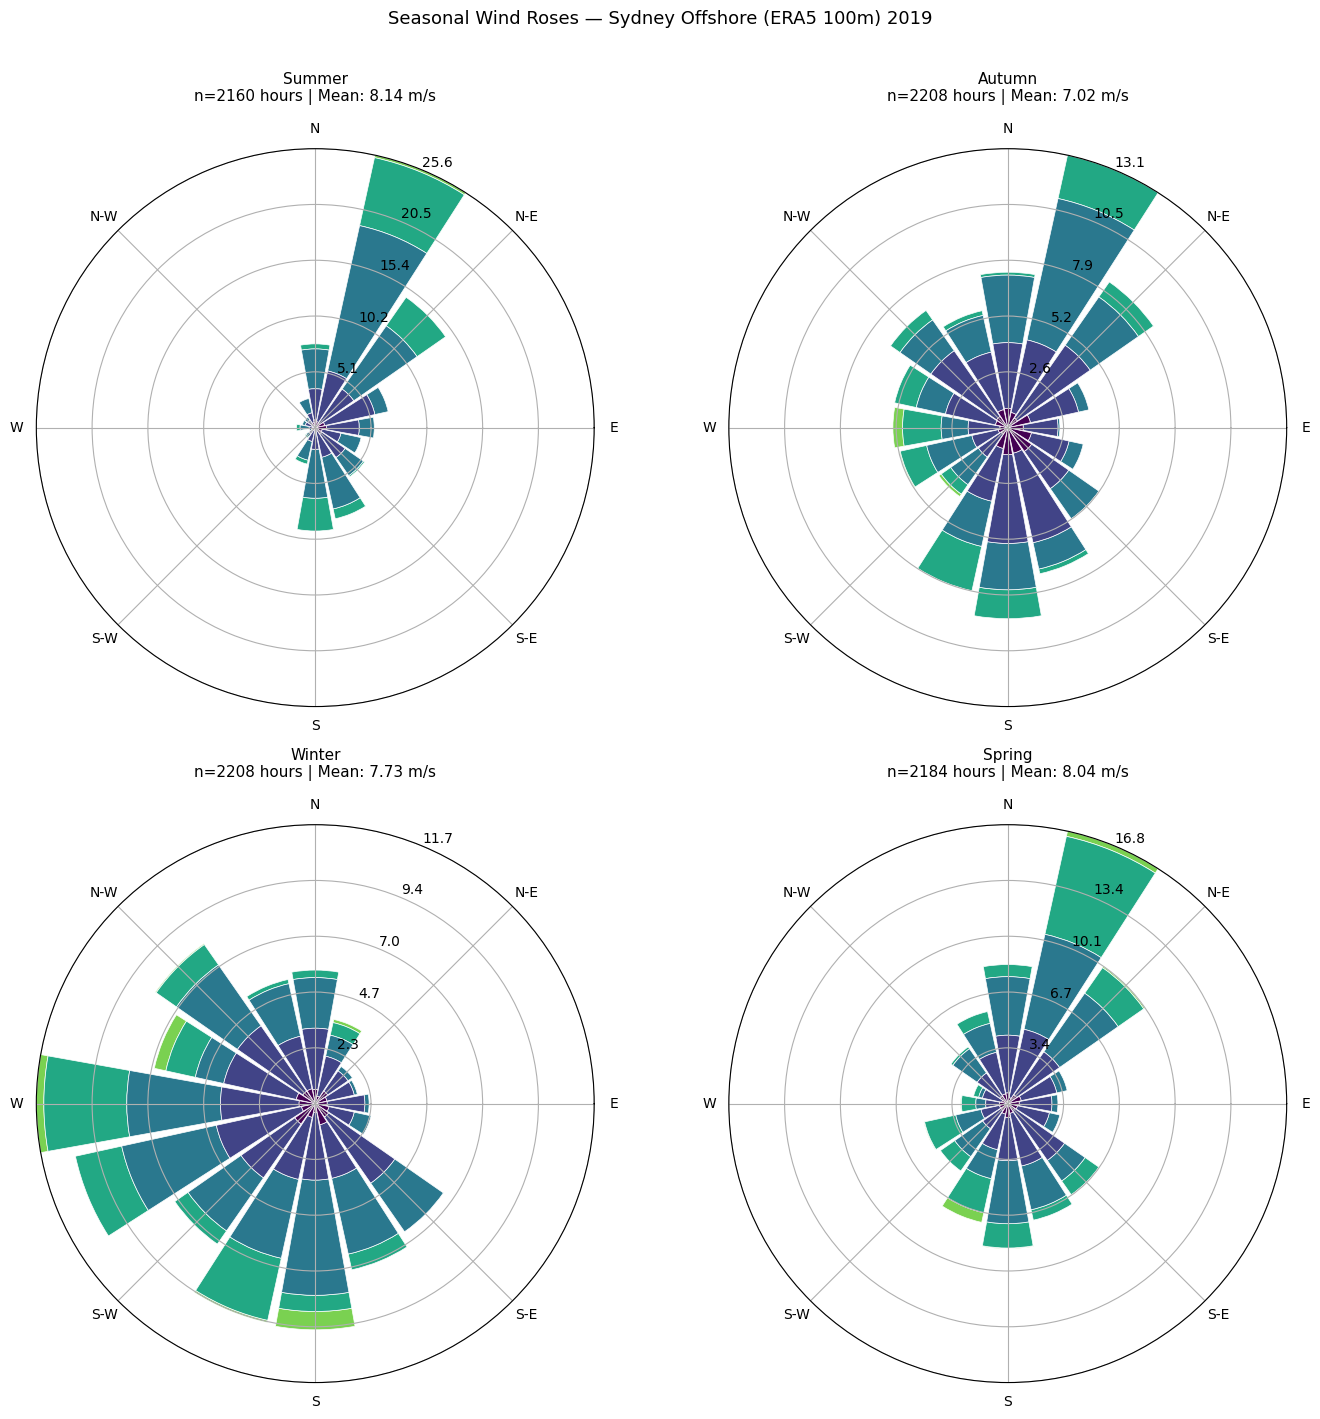

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14),
                          subplot_kw=dict(projection="windrose"))

seasons = ["Summer", "Autumn", "Winter", "Spring"]
colours = ["#FF6B6B", "#FFA07A", "#4169E1", "#32CD32"]
positions = [(0,0), (0,1), (1,0), (1,1)]

for season, (row, col) in zip(seasons, positions):
    mask = df_2019["season"] == season
    season_data = df_2019[mask]
    n_hours = mask.sum()
    mean_spd = season_data["wind_speed"].mean()
    
    ax = axes[row, col]
    ax = WindroseAxes.from_ax(ax=ax)
    
    ax.bar(season_data["wind_direction"],
           season_data["wind_speed"],
           normed=True,
           opening=0.9,
           edgecolor="white",
           linewidth=0.5,
           bins=[0, 3, 7, 12, 18, 25],
           nsector=16)
    
    ax.set_title(f"{season}\n"
                 f"n={n_hours} hours | Mean: {mean_spd:.2f} m/s",
                 fontsize=11, pad=15)

plt.suptitle("Seasonal Wind Roses — Sydney Offshore (ERA5 100m) 2019",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/figures/07_seasonal_wind_roses_2019.png",
            dpi=150, bbox_inches="tight")
plt.show()

=== POWER CURVE VERIFICATION ===
Speed (m/s)      Power (kW) Notes
--------------------------------------------------
0.0                     0.0   below cut-in
3.0                    40.0   cut-in speed
5.0                   403.0   power zone
7.0                  1116.0   power zone
9.0                  2100.0   power zone
11.4                 3500.0   rated speed
12.0                 3500.0   rated (plateau)
15.0                 3500.0   rated (plateau)
25.0                 3500.0   cut-out speed
26.0                    0.0   above cut-out


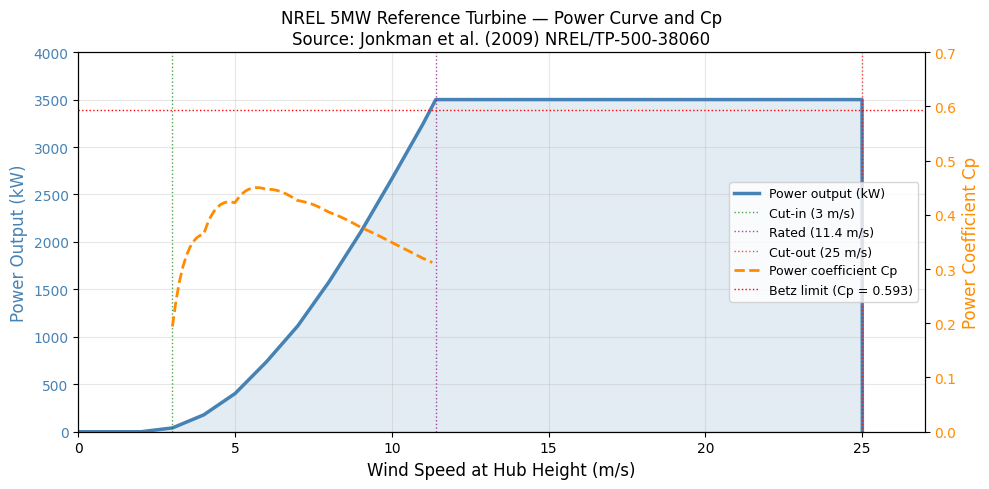

In [21]:
from scipy.interpolate import interp1d

# NREL 5MW Reference Turbine power curve
# Source: Jonkman et al. (2009) NREL/TP-500-38060
# Wind speed in m/s, Power in kW
# These values are taken directly from the published technical report

nrel_5mw_curve = {
    "wind_speed": [
        0.0,  1.0,  2.0,  3.0,  4.0,  5.0,  6.0,  7.0,  8.0,
        9.0, 10.0, 11.0, 11.4, 12.0, 13.0, 14.0, 15.0, 16.0,
       17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 25.01
    ],
    "power_kw": [
           0,    0,    0,   40,  178,  403,  737, 1116, 1582,
        2100, 2665, 3248, 3500, 3500, 3500, 3500, 3500, 3500,
        3500, 3500, 3500, 3500, 3500, 3500, 3500, 3500, 3500,    0
    ]
}

# Convert to numpy arrays
u_curve = np.array(nrel_5mw_curve["wind_speed"])
p_curve = np.array(nrel_5mw_curve["power_kw"])

# Create interpolation function
# bounds_error=False and fill_value=0 means any speed outside
# the curve range (below 0 or above 25.01) returns zero power
# This handles cut-in and cut-out automatically
power_curve_fn = interp1d(
    u_curve,
    p_curve,
    kind="linear",
    bounds_error=False,
    fill_value=0.0
)

# Verify the interpolation at key reference points
print("=== POWER CURVE VERIFICATION ===")
test_speeds = [0, 3, 5, 7, 9, 11.4, 12, 15, 25, 26]
print(f"{'Speed (m/s)':<14} {'Power (kW)':>12} {'Notes'}")
print("-" * 50)
notes = [
    "below cut-in",
    "cut-in speed",
    "power zone",
    "power zone",
    "power zone",
    "rated speed",
    "rated (plateau)",
    "rated (plateau)",
    "cut-out speed",
    "above cut-out"
]
for speed, note in zip(test_speeds, notes):
    power = power_curve_fn(speed)
    print(f"{speed:<14.1f} {power:>12.1f}   {note}")

# Plot the power curve
fig, ax1 = plt.subplots(figsize=(10, 5))

# Power curve
ax1.plot(u_curve, p_curve,
         color="steelblue", linewidth=2.5, label="Power output (kW)")
ax1.fill_between(u_curve, p_curve, alpha=0.15, color="steelblue")
ax1.set_xlabel("Wind Speed at Hub Height (m/s)", fontsize=12)
ax1.set_ylabel("Power Output (kW)", fontsize=12, color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_ylim(0, 4000)

# Add Cp curve on secondary axis
# Cp = P / (0.5 * rho * A * U³)
# Using standard air density rho = 1.225 kg/m³, rotor area = π×63² m²
rho = 1.225
R = 63.0
A = np.pi * R**2
u_plot = np.linspace(3, 25, 200)
p_plot = power_curve_fn(u_plot) * 1000  # convert kW to W

# Avoid division by zero and only calculate Cp in power zone
with np.errstate(divide="ignore", invalid="ignore"):
    cp_values = np.where(
        u_plot < 11.4,
        p_plot / (0.5 * rho * A * u_plot**3),
        np.nan
    )

ax2 = ax1.twinx()
ax2.plot(u_plot, cp_values,
         color="darkorange", linewidth=2.0,
         linestyle="--", label="Power coefficient Cp")
ax2.axhline(16/27, color="red", linewidth=1.0, linestyle=":",
            label=f"Betz limit (Cp = {16/27:.3f})")
ax2.set_ylabel("Power Coefficient Cp", fontsize=12, color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")
ax2.set_ylim(0, 0.7)

# Reference lines
ax1.axvline(3.0, color="green", linewidth=1.0,
            linestyle=":", alpha=0.7, label="Cut-in (3 m/s)")
ax1.axvline(11.4, color="purple", linewidth=1.0,
            linestyle=":", alpha=0.7, label="Rated (11.4 m/s)")
ax1.axvline(25.0, color="red", linewidth=1.0,
            linestyle=":", alpha=0.7, label="Cut-out (25 m/s)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           fontsize=9, loc="center right")

ax1.set_title("NREL 5MW Reference Turbine — Power Curve and Cp\n"
              "Source: Jonkman et al. (2009) NREL/TP-500-38060",
              fontsize=12)
ax1.set_xlim(0, 27)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/figures/08_power_curve_nrel5mw.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [22]:
# Hub height wind speed correction using power law
# U(z) = U_ref × (z/z_ref)^alpha
#
# z_ref = 100m (ERA5 reference height)
# z_hub = 90m  (NREL 5MW hub height)
# alpha = 0.11 (offshore wind shear exponent)
#
# Alpha choice: offshore wind shear is lower than onshore
# because the ocean surface is aerodynamically smooth
# Typical values:
#   Offshore open ocean:  0.10 - 0.12
#   Coastal offshore:     0.11 - 0.14
#   Flat onshore:         0.14 - 0.16
#   Complex terrain:      0.20 - 0.30
# We use 0.11 as representative of an open offshore location

Z_REF = 100.0   # ERA5 wind height, m
Z_HUB = 90.0    # NREL 5MW hub height, m
ALPHA = 0.11    # offshore shear exponent

shear_factor = (Z_HUB / Z_REF) ** ALPHA

print("=== HUB HEIGHT CORRECTION ===")
print(f"  ERA5 reference height:  {Z_REF:.0f} m")
print(f"  Turbine hub height:     {Z_HUB:.0f} m")
print(f"  Shear exponent alpha:   {ALPHA}")
print(f"  Shear correction factor: {shear_factor:.6f}")
print(f"  Effect: wind speeds scaled by {shear_factor:.4f}")
print(f"  (100m → 90m is a downward correction since hub is below ERA5 height)")

# Apply correction to Weibull scale parameter
# Since U_hub = U_100 × shear_factor, and Weibull scales linearly with speed,
# correcting lambda is equivalent to correcting every wind speed observation
# This is more elegant than correcting 8760 individual values
lambda_hub = lam * shear_factor
k_hub = k  # shape parameter is dimensionless, unaffected by height scaling

print(f"\n=== CORRECTED WEIBULL PARAMETERS AT HUB HEIGHT ===")
print(f"  k (shape):    {k_hub:.4f}  (unchanged)")
print(f"  λ at 100m:    {lam:.4f} m/s")
print(f"  λ at 90m:     {lambda_hub:.4f} m/s")

# Recalculate mean at hub height
mean_hub = lambda_hub * math.gamma(1 + 1/k_hub)
print(f"  Mean speed at hub height: {mean_hub:.4f} m/s")
print(f"  Mean speed at 100m:       {lam * math.gamma(1 + 1/k):.4f} m/s")
print(f"  Difference:               {abs(mean_hub - lam * math.gamma(1+1/k)):.4f} m/s")

=== HUB HEIGHT CORRECTION ===
  ERA5 reference height:  100 m
  Turbine hub height:     90 m
  Shear exponent alpha:   0.11
  Shear correction factor: 0.988477
  Effect: wind speeds scaled by 0.9885
  (100m → 90m is a downward correction since hub is below ERA5 height)

=== CORRECTED WEIBULL PARAMETERS AT HUB HEIGHT ===
  k (shape):    2.1109  (unchanged)
  λ at 100m:    8.7630 m/s
  λ at 90m:     8.6620 m/s
  Mean speed at hub height: 7.6717 m/s
  Mean speed at 100m:       7.7611 m/s
  Difference:               0.0894 m/s


In [23]:
from scipy import stats
from scipy import integrate

# AEP calculation using numerical integration of power curve × Weibull PDF
#
# AEP = 8760 × ∫ P(U) × f(U) dU
#
# where:
#   P(U) = power curve function (kW)
#   f(U) = Weibull PDF at hub height
#   8760 = hours per year

# Define speed range for integration
# Start slightly above 0 to avoid PDF edge effects
# End at cut-out + small margin
U_MIN = 0.01
U_MAX = 26.0
N_POINTS = 10000  # fine resolution for accurate integration

u_integration = np.linspace(U_MIN, U_MAX, N_POINTS)

# Evaluate Weibull PDF at each speed using hub-height corrected parameters
pdf_hub = stats.weibull_min.pdf(
    u_integration,
    c=k_hub,
    loc=0,
    scale=lambda_hub
)

# Evaluate power curve at each speed
power_at_u = power_curve_fn(u_integration)  # kW

# Integrand: P(U) × f(U)
integrand = power_at_u * pdf_hub

# Numerical integration using Simpson's rule
# Simpson's rule is more accurate than simple trapezoid for smooth functions
mean_power_kw = integrate.simpson(integrand, x=u_integration)

# Scale to annual energy
hours_per_year = 8760
gross_aep_mwh = mean_power_kw * hours_per_year / 1000  # convert kWh to MWh
gross_aep_gwh = gross_aep_mwh / 1000

# Apply availability factor
# Industry standard ~95% — accounts for planned maintenance,
# unplanned downtime, grid curtailment
availability = 0.95
net_aep_mwh = gross_aep_mwh * availability
net_aep_gwh = net_aep_mwh / 1000

# Capacity factor: ratio of actual output to theoretical maximum
# CF = AEP / (rated_power × 8760 hours)
rated_power_mw = 5.0
capacity_factor_gross = gross_aep_mwh / (rated_power_mw * hours_per_year)
capacity_factor_net = net_aep_mwh / (rated_power_mw * hours_per_year)

print("=" * 50)
print("   AEP RESULTS — NREL 5MW — SYDNEY OFFSHORE")
print("=" * 50)
print(f"\n  Site:          -34.0°N, 151.75°E (ERA5)")
print(f"  Data period:   2019 (single year)")
print(f"  Hub height:    {Z_HUB:.0f} m")
print(f"  Weibull k:     {k_hub:.4f}")
print(f"  Weibull λ:     {lambda_hub:.4f} m/s")
print(f"  Mean speed:    {mean_hub:.2f} m/s at hub height")

print(f"\n  --- Energy Output ---")
print(f"  Mean power:         {mean_power_kw:.1f} kW")
print(f"  Gross AEP:          {gross_aep_mwh:.0f} MWh/year")
print(f"  Gross AEP:          {gross_aep_gwh:.3f} GWh/year")
print(f"  Net AEP (95% avail):{net_aep_mwh:.0f} MWh/year")
print(f"  Net AEP:            {net_aep_gwh:.3f} GWh/year")

print(f"\n  --- Performance Metrics ---")
print(f"  Gross capacity factor: {capacity_factor_gross:.1%}")
print(f"  Net capacity factor:   {capacity_factor_net:.1%}")

print(f"\n  --- Assumptions ---")
print(f"  Availability factor:   {availability:.0%}")
print(f"  Wake losses:           Not modelled (single turbine)")
print(f"  Electrical losses:     Not modelled")
print(f"  Shear exponent:        {ALPHA} (offshore)")
print(f"  ERA5 mesoscale bias:   Not corrected")

   AEP RESULTS — NREL 5MW — SYDNEY OFFSHORE

  Site:          -34.0°N, 151.75°E (ERA5)
  Data period:   2019 (single year)
  Hub height:    90 m
  Weibull k:     2.1109
  Weibull λ:     8.6620 m/s
  Mean speed:    7.67 m/s at hub height

  --- Energy Output ---
  Mean power:         1542.6 kW
  Gross AEP:          13513 MWh/year
  Gross AEP:          13.513 GWh/year
  Net AEP (95% avail):12838 MWh/year
  Net AEP:            12.838 GWh/year

  --- Performance Metrics ---
  Gross capacity factor: 30.9%
  Net capacity factor:   29.3%

  --- Assumptions ---
  Availability factor:   95%
  Wake losses:           Not modelled (single turbine)
  Electrical losses:     Not modelled
  Shear exponent:        0.11 (offshore)
  ERA5 mesoscale bias:   Not corrected


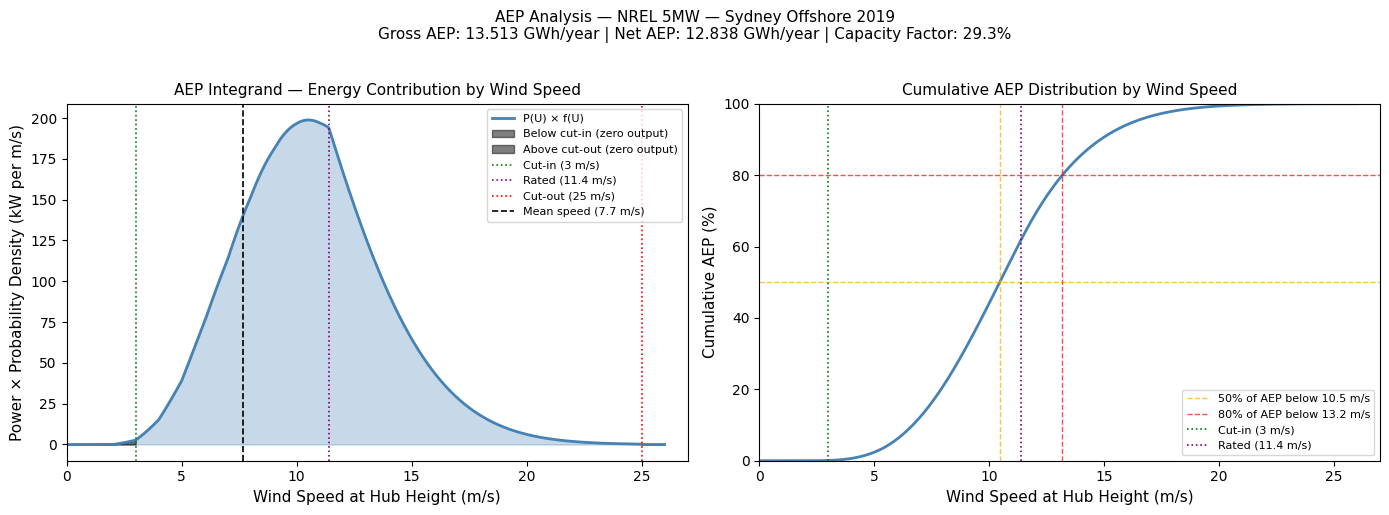

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left panel: Power weighted by probability ---
# This shows the contribution of each wind speed bin to total AEP
# The area under this curve integrates to mean power output

ax = axes[0]
ax.plot(u_integration, integrand,
        color="steelblue", linewidth=2.0,
        label="P(U) × f(U)")
ax.fill_between(u_integration, integrand,
                alpha=0.3, color="steelblue")

# Shade the cut-in and cut-out regions
ax.fill_between(u_integration, integrand,
                where=(u_integration < 3.0),
                alpha=0.5, color="black",
                label="Below cut-in (zero output)")
ax.fill_between(u_integration, integrand,
                where=(u_integration > 25.0),
                alpha=0.5, color="black",
                label="Above cut-out (zero output)")

ax.axvline(3.0, color="green", linewidth=1.2,
           linestyle=":", label="Cut-in (3 m/s)")
ax.axvline(11.4, color="purple", linewidth=1.2,
           linestyle=":", label="Rated (11.4 m/s)")
ax.axvline(25.0, color="red", linewidth=1.2,
           linestyle=":", label="Cut-out (25 m/s)")
ax.axvline(mean_hub, color="black", linewidth=1.2,
           linestyle="--", label=f"Mean speed ({mean_hub:.1f} m/s)")

ax.set_xlabel("Wind Speed at Hub Height (m/s)", fontsize=11)
ax.set_ylabel("Power × Probability Density (kW per m/s)", fontsize=11)
ax.set_title("AEP Integrand — Energy Contribution by Wind Speed", fontsize=11)
ax.legend(fontsize=8)
ax.set_xlim(0, 27)

# --- Right panel: Cumulative AEP by wind speed ---
# Shows what fraction of total AEP comes from speeds below each threshold
# Useful for understanding which speed range dominates energy production

cumulative_integrand = np.cumsum(integrand) * (U_MAX - U_MIN) / N_POINTS
cumulative_aep_fraction = cumulative_integrand / cumulative_integrand[-1]

ax2 = axes[1]
ax2.plot(u_integration, cumulative_aep_fraction * 100,
         color="steelblue", linewidth=2.0)

# Mark the speed below which 50% and 80% of AEP is captured
for target_pct, colour in [(50, "orange"), (80, "red")]:
    idx = np.searchsorted(cumulative_aep_fraction, target_pct/100)
    if idx < len(u_integration):
        speed_at_pct = u_integration[idx]
        ax2.axhline(target_pct, color=colour, linewidth=1.0,
                    linestyle="--", alpha=0.7)
        ax2.axvline(speed_at_pct, color=colour, linewidth=1.0,
                    linestyle="--", alpha=0.7,
                    label=f"{target_pct}% of AEP below {speed_at_pct:.1f} m/s")

ax2.axvline(3.0, color="green", linewidth=1.2,
            linestyle=":", label="Cut-in (3 m/s)")
ax2.axvline(11.4, color="purple", linewidth=1.2,
            linestyle=":", label="Rated (11.4 m/s)")

ax2.set_xlabel("Wind Speed at Hub Height (m/s)", fontsize=11)
ax2.set_ylabel("Cumulative AEP (%)", fontsize=11)
ax2.set_title("Cumulative AEP Distribution by Wind Speed", fontsize=11)
ax2.legend(fontsize=8)
ax2.set_xlim(0, 27)
ax2.set_ylim(0, 100)

plt.suptitle(f"AEP Analysis — NREL 5MW — Sydney Offshore 2019\n"
             f"Gross AEP: {gross_aep_gwh:.3f} GWh/year | "
             f"Net AEP: {net_aep_gwh:.3f} GWh/year | "
             f"Capacity Factor: {capacity_factor_net:.1%}",
             fontsize=11, y=1.02)

plt.tight_layout()
plt.savefig("../outputs/figures/09_aep_analysis_2019.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [50]:
import yaml
from pathlib import Path

# Path navigates up one level from notebooks/ to project root
config_path = Path("../config.yaml")

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

print("Config loaded successfully")
print(f"\nSite:      {config['site']['name']}")
print(f"Lat/Lon:   {config['site']['latitude']}°N, "
      f"{config['site']['longitude']}°E")
print(f"Years:     {config['era5']['years']}")
print(f"Hub height:{config['turbine']['hub_height_m']}m")
print(f"Turbine:   {config['turbine']['name']}")

Config loaded successfully

Site:      Sydney Offshore
Lat/Lon:   -34.0°N, 151.75°E
Years:     [2019, 2020, 2021, 2022, 2023]
Hub height:90.0m
Turbine:   NREL 5MW Reference


In [1]:
import sys
from pathlib import Path

# Add project root to path so Python can find the src package
# This is needed because the notebook lives in notebooks/ 
# but src/ is one level up
sys.path.insert(0, str(Path("..").resolve()))

from src.process_wind import load_era5_year, add_temporal_features, basic_diagnostics
import yaml

# Load config
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Test loading 2019
df_test = load_era5_year(
    year=2019,
    data_dir=f"../{config['paths']['raw_data']}",
    lat=config['site']['latitude'],
    lon=config['site']['longitude']
)

# Add temporal features
df_test = add_temporal_features(df_test)

# Run diagnostics
diags = basic_diagnostics(df_test)

print(f"\nDataFrame shape: {df_test.shape}")
print(f"Columns: {list(df_test.columns)}")
print(f"\nFirst 3 rows:")
print(df_test.head(3))

=== WIND SPEED DIAGNOSTICS ===
  Hours:              8,760
  Mean:               7.73 m/s
  Median:             7.23 m/s
  Std deviation:      3.90 m/s
  Max:                23.21 m/s
  % below cut-in:     10.0%
  % above rated:      15.9%
  % above cut-out:    0.0%
  Missing values:     0

DataFrame shape: (8760, 6)
Columns: ['u100', 'v100', 'wind_speed', 'wind_direction', 'month', 'season']

First 3 rows:
                         u100      v100  wind_speed  wind_direction  month  \
time                                                                         
2019-01-01 00:00:00 -1.203949 -6.389709    6.502144       10.670568      1   
2019-01-01 01:00:00 -0.872925 -6.765488    6.821570        7.352035      1   
2019-01-01 02:00:00 -0.607254 -5.956268    5.987144        5.821311      1   

                     season  
time                         
2019-01-01 00:00:00  Summer  
2019-01-01 01:00:00  Summer  
2019-01-01 02:00:00  Summer  


In [2]:
from src.weibull import fit_weibull, apply_hub_correction, goodness_of_fit

# Use the df_test we loaded via process_wind
wind_speeds = df_test["wind_speed"].values

# Fit Weibull
weibull_result = fit_weibull(
    wind_speeds,
    calm_threshold=config["era5"]["calm_threshold_ms"]
)

# Apply hub height correction
weibull_hub = apply_hub_correction(
    weibull_result,
    z_ref=config["era5"]["reference_height_m"],
    z_hub=config["turbine"]["hub_height_m"],
    alpha=config["turbine"]["shear_exponent"]
)

# Goodness of fit
gof = goodness_of_fit(wind_speeds, weibull_result)

=== WEIBULL FIT RESULTS ===
  Shape parameter  k:   2.1109
  Scale parameter  λ:   8.7630 m/s
  Observations used:    8,738
  Calm hours excluded:  22 (0.3%)
  Theoretical mean:     7.7611 m/s
  Observed mean:        7.7301 m/s
  Mean error:           0.0310 m/s
  Interpretation:       k=2.11 — moderately consistent

=== HUB HEIGHT CORRECTION ===
  Reference height:     100 m
  Hub height:           90 m
  Shear exponent α:     0.11
  Shear factor:         0.988477
  λ at 100m:          8.7630 m/s
  λ at 90m:           8.6620 m/s
  Mean at hub height:   7.6717 m/s

=== GOODNESS OF FIT ===
  KS statistic D:  0.0186
  p-value:         0.0048
  n observations:  8,738
  Result:          Formally rejected (p=0.0048) but D=0.0186 is practically small — expected with n=8,738 samples


=== AEP RESULTS ===
  Mean power:             1542.6 kW
  Gross AEP:              13.513 GWh/year
  Net AEP (95% avail):   12.838 GWh/year
  Gross capacity factor:  30.9%
  Net capacity factor:    29.3%
Figure saved: ../outputs/figures/aep_analysis_2019.png


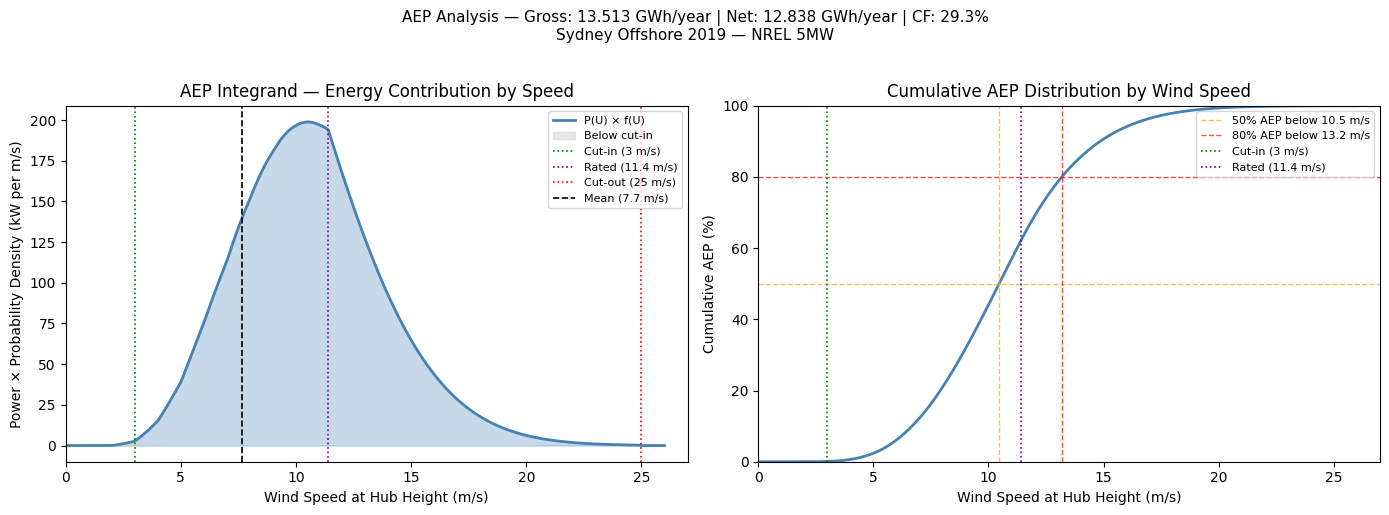

In [3]:
from src.aep import build_power_curve, calculate_aep, plot_aep_analysis

# Build power curve
power_fn = build_power_curve()

# Calculate AEP using hub-corrected Weibull parameters
aep_result = calculate_aep(
    k_hub          = weibull_hub["k_hub"],
    lam_hub        = weibull_hub["lam_hub"],
    power_fn       = power_fn,
    availability   = config["turbine"]["availability"],
    rated_power_mw = config["turbine"]["rated_power_mw"]
)

# Plot
plot_aep_analysis(
    k_hub      = weibull_hub["k_hub"],
    lam_hub    = weibull_hub["lam_hub"],
    power_fn   = power_fn,
    aep_result = aep_result,
    title      = "Sydney Offshore 2019 — NREL 5MW",
    save_path  = "../outputs/figures/aep_analysis_2019.png"
)

=== DIRECTIONAL ANALYSIS ===
Sector  Centre     Freq   Mean U   Max U   > Rated   Energy
--------------------------------------------------------------
N         0.0°      7.2%     7.12    16.22       5.7%     4.8%  ████
NNE      22.5°     14.7%     9.44    19.59      26.6%    21.8%  █████████
NE       45.0°      8.7%     8.00    18.98      17.2%     8.5%  █████
ENE      67.5°      4.0%     4.85    10.22       0.0%     0.8%  ██
E        90.0°      3.3%     4.76    11.08       0.0%     0.7%  ██
ESE     112.5°      3.4%     5.37    11.28       0.0%     1.2%  ██
SE      135.0°      6.0%     6.23    17.49       4.8%     3.1%  ███
SSE     157.5°      7.5%     7.05    16.06       8.2%     5.1%  ████
S       180.0°      9.2%     8.58    23.21      19.9%    11.5%  ██████
SSW     202.5°      7.0%     8.92    22.25      28.5%    10.4%  ████
SW      225.0°      4.3%     7.66    18.17      14.8%     4.4%  ██
WSW     247.5°      5.4%     8.72    21.71      24.9%     7.0%  ███
W       270.0°      5.

C:\Users\Aidan\OneDrive\Documents\Engineering Projects\wind-data-analysis\src\wind_rose.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figure saved: ../outputs/figures/wind_rose_2019.png


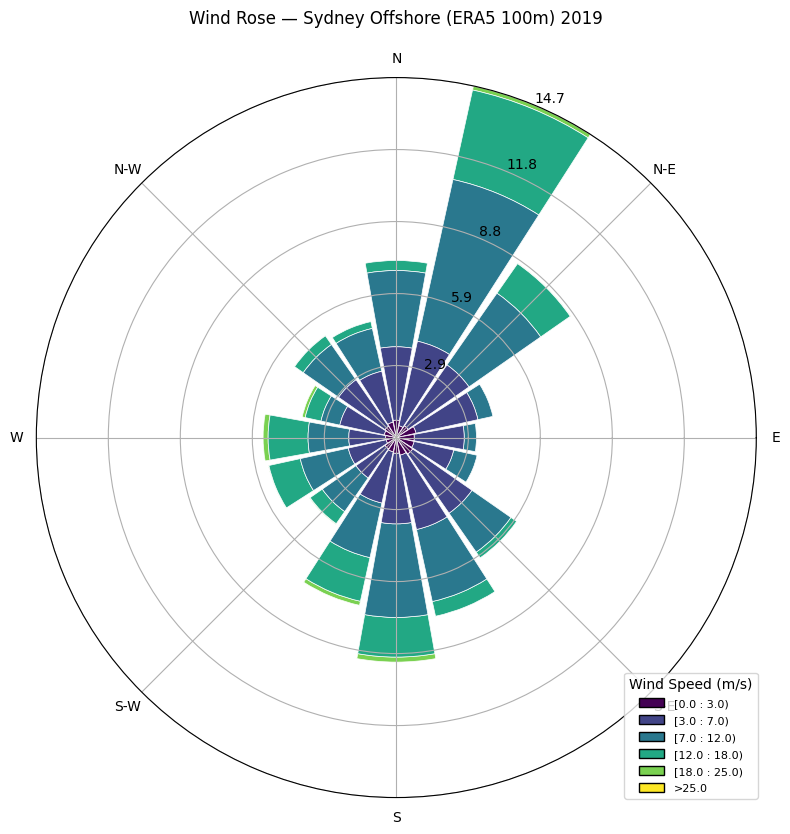

Figure saved: ../outputs/figures/seasonal_roses_2019.png


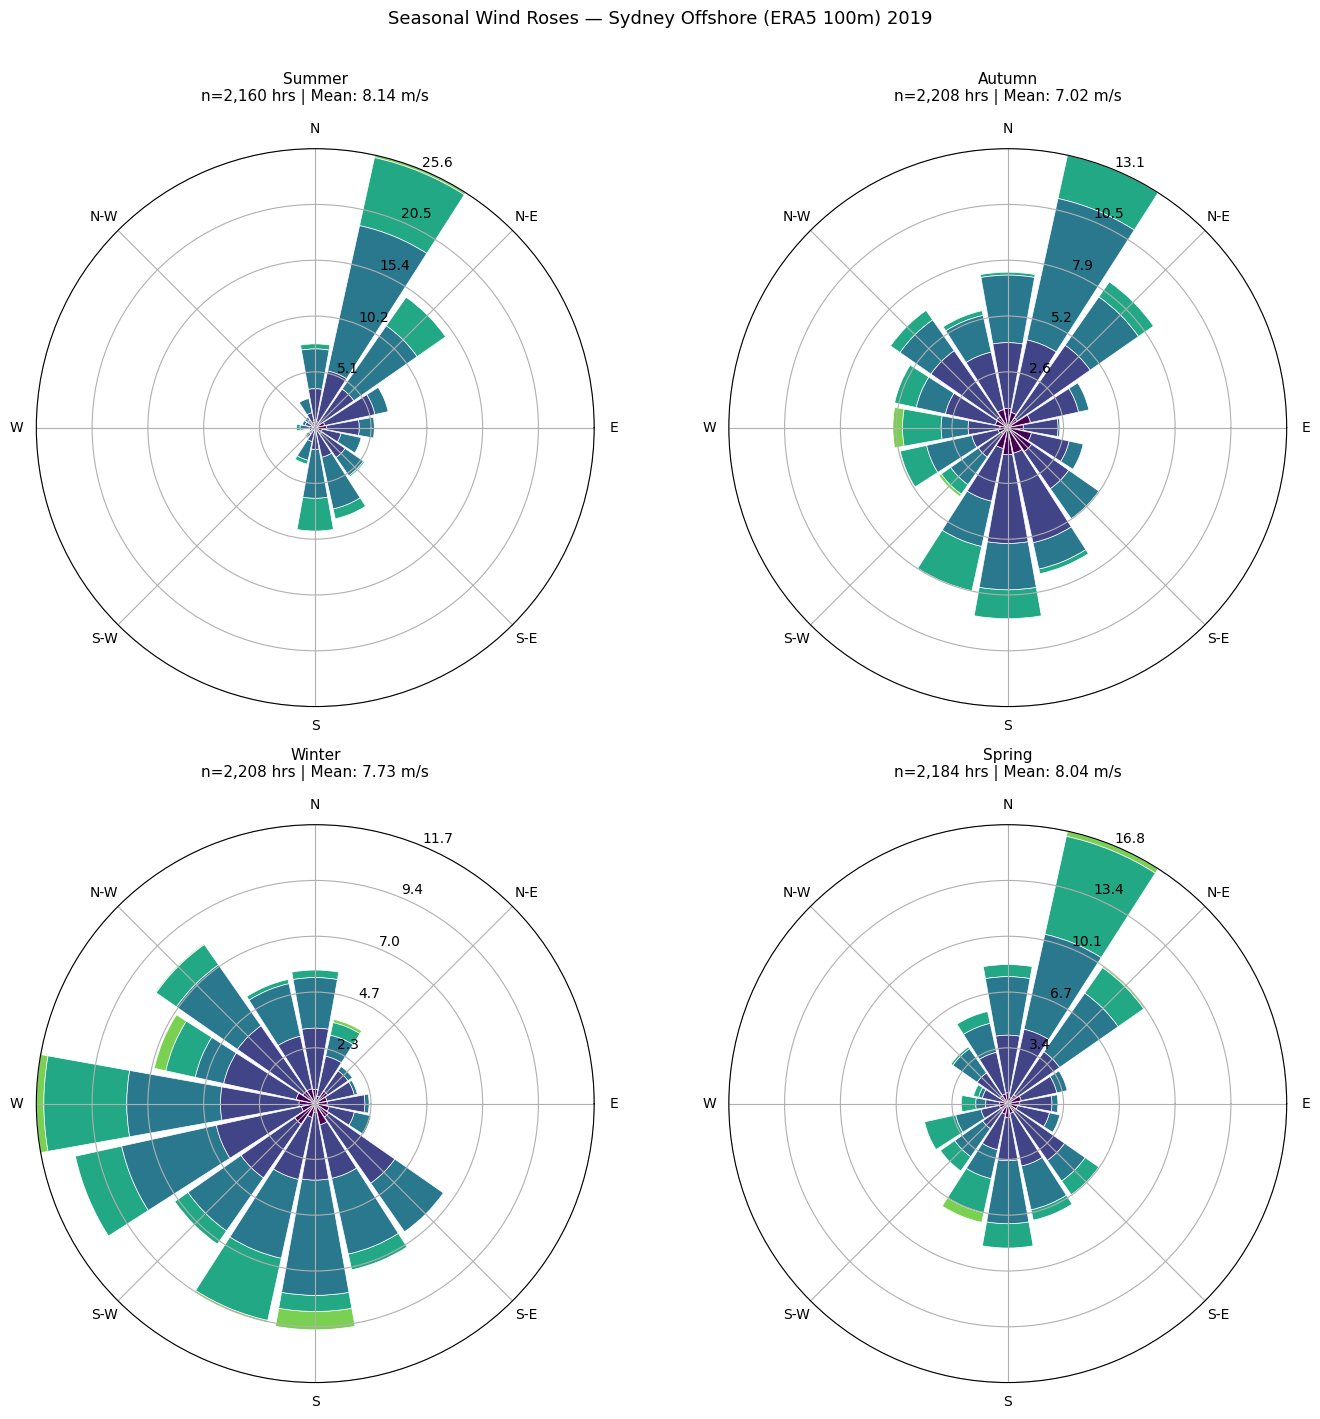

In [4]:
from src.wind_rose import (directional_statistics,
                            print_directional_table,
                            plot_wind_rose,
                            plot_seasonal_roses)
from src.process_wind import add_temporal_features

# Add season column if not already present
df_test = add_temporal_features(df_test)

# Directional statistics
df_sectors = directional_statistics(df_test)
print_directional_table(df_sectors)

# Wind rose
plot_wind_rose(
    df_test,
    title="Wind Rose — Sydney Offshore (ERA5 100m) 2019",
    save_path="../outputs/figures/wind_rose_2019.png"
)

# Seasonal roses
plot_seasonal_roses(
    df_test,
    title="Seasonal Wind Roses — Sydney Offshore (ERA5 100m) 2019",
    save_path="../outputs/figures/seasonal_roses_2019.png"
)